# Experiment - ResNet50 on whole slides

The first approach: classify each slide as a single image. Slides are cleaned of green blob artifacts through HSV thresholding, cropped to the tissue bounding box with a 5% margin, resized to 512x512, and fed to an ImageNet-pretrained ResNet50 with the lower layers frozen for three warmup epochs.

**Test F1: 0.3768.** Resizing a whole slide to 512x512 destroys exactly the cellular detail the subtypes differ by, which is what motivated the move to tiles.

---


## Drive Connection


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain train_data/, test_data/ and train_labels.csv
# (see data/README.md).
import os

DATA_DIR = os.environ.get("WSI_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Libraries Import


In [25]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.9.0+cu126
Device: cuda


## Data Cleaning


After having manually removed 60 Shrek-tissues from the train set, now we filter the train labels file and the train mask directory by removing the correspondent records.

## Read files and directory


In [26]:
import pandas as pd
from pathlib import Path
import re

train_img_dir = Path("Dataset/train_img_data")
train_mask_dir = Path("Dataset/train_mask_data")
labels_path = Path("Dataset/train_labels.csv")

# 1) All available images after your manual Shrek purge
img_paths = sorted(train_img_dir.glob("img_*.png"))

def get_id_from_img(path):
    m = re.search(r"img_(\d+)\.png", path.name)
    return m.group(1)

available_ids = {get_id_from_img(p) for p in img_paths}
print("Number of images in freeshrek_train_data:", len(available_ids))

# 2) Load labels and extract numeric id from sample_index
df = pd.read_csv(labels_path)

def extract_id_from_sample_index(s):
    m = re.search(r"img_(\d+)", str(s))
    return m.group(1)

df["id"] = df["sample_index"].apply(extract_id_from_sample_index)
print("Rows in original labels:", len(df))

# 3) Keep only rows for which we still have an image
df_filtered = df[df["id"].isin(available_ids)].copy()
print("Rows after filtering:", len(df_filtered))  # should be ~631


Number of images in freeshrek_train_data: 1262
Rows in original labels: 580
Rows after filtering: 580


## Cleaning


In [27]:
import shutil

clean_img_dir = Path("clean_train_data")
clean_mask_dir = Path("clean_train_mask")
clean_img_dir.mkdir(exist_ok=True)
clean_mask_dir.mkdir(exist_ok=True)

# deterministic order
df_filtered = df_filtered.sort_values("id").reset_index(drop=True)

id_mapping = {}   # old_id -> new_id

for new_idx, row in enumerate(df_filtered.itertuples(index=False)):
    old_id = row.id
    new_id = f"{new_idx:04d}"

    id_mapping[old_id] = new_id

    # copy & rename image
    src_img = train_img_dir / f"img_{old_id}.png"
    dst_img = clean_img_dir / f"img_{new_id}.png"
    if not src_img.exists():
        raise FileNotFoundError(f"Missing image: {src_img}")
    shutil.copy2(src_img, dst_img)

    # copy & rename mask
    src_mask = train_mask_dir / f"mask_{old_id}.png"
    dst_mask = clean_mask_dir / f"mask_{new_id}.png"
    if not src_mask.exists():
        raise FileNotFoundError(f"Missing mask for id {old_id}: {src_mask}")
    shutil.copy2(src_mask, dst_mask)

print("Copied and renamed", len(df_filtered), "pairs.")


Copied and renamed 580 pairs.


In [28]:
def remap_sample_index(s):
    old_id = extract_id_from_sample_index(s)
    new_id = id_mapping[old_id]
    return f"img_{new_id}.png"

df_filtered["sample_index"] = df_filtered["sample_index"].apply(remap_sample_index)
df_clean_labels = df_filtered.drop(columns=["id"])

clean_labels_path = Path("clean_train_labels.csv")
df_clean_labels.to_csv(clean_labels_path, index=False)

print("Clean labels saved to:", clean_labels_path)
print("Rows in clean labels:", len(df_clean_labels))
print("Clean img files:", len(list(clean_img_dir.glob('img_*.png'))))
print("Clean mask files:", len(list(clean_mask_dir.glob('mask_*.png'))))

Clean labels saved to: clean_train_labels.csv
Rows in clean labels: 580
Clean img files: 580
Clean mask files: 580


## Data Preprocessing


Let's see the actual image size

In [29]:
from pathlib import Path
from PIL import Image
import pandas as pd

img_dir = Path("train_data")   # your cleaned directory
sizes = []

for p in img_dir.glob("img_*.png"):
    with Image.open(p) as im:
        w, h = im.size
        sizes.append((p.name, w, h))

df_sizes = pd.DataFrame(sizes, columns=["filename", "width", "height"])
print(df_sizes.describe())

       filename width height
count         0     0      0
unique        0     0      0
top         NaN   NaN    NaN
freq        NaN   NaN    NaN


## Creating .npz files


In [30]:
# If needed: !pip install -q opencv-python-headless

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import cv2

IMG_SIZE = 512
MARGIN_FACTOR = 1.05  # instead of 1.15
  # padding around tissue bbox
MIN_TISSUE_FRAC = 0.002  # 0.2% of image area
MIN_COMPONENT_FRAC = 0.001  # min area for each component

train_img_dir = Path("Dataset/train_img_data")
train_mask_dir = Path("Dataset/train_mask_data")
labels_path   = Path("Dataset/train_labels.csv")

df = pd.read_csv(labels_path)

# encode labels
labels_sorted = sorted(df["label"].unique())
label2idx = {lbl: i for i, lbl in enumerate(labels_sorted)}
y = df["label"].map(label2idx).values.astype(np.int64)


# ---------- blob detection (HSV) ----------

def detect_blob_pixels(img_np):
    """
    Aggressive blob detection using HSV.
    OpenCV HSV ranges: H in [0,179], S,V in [0,255].
    """
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    # Wider green hue band, relaxed S/V
    base = (
        (H >= 25) & (H <= 100) &   # green-ish / yellow-green band
        (S >= 80) &
        (V >= 80)
    )

    # Slightly emphasize pixels where G really dominates in RGB
    R = img_np[:, :, 0].astype(np.int16)
    G = img_np[:, :, 1].astype(np.int16)
    B = img_np[:, :, 2].astype(np.int16)
    dom_g = (G - R > 20) & (G - B > 20)

    blob = base & dom_g

    # Dilate a bit to cover the glossy border
    kernel = np.ones((7, 7), np.uint8)
    blob_dilated = cv2.dilate(blob.astype(np.uint8), kernel, iterations=1).astype(bool)
    return blob_dilated


def remove_blob(img_np, mask_bin):
    """
    Detect blob pixels, replace with background color,
    and remove them from the mask.
    """
    blob_mask = detect_blob_pixels(img_np)

    if not blob_mask.any():
        # no blob detected
        return img_np, mask_bin

    # For background estimate we use original (approx) tissue mask
    bg_color = estimate_background_color(img_np, mask_bin, blob_mask)

    img_clean = img_np.copy()
    img_clean[blob_mask] = bg_color

    mask_clean = mask_bin & (~blob_mask)


    # Plot original and cleaned images side by side
    plt.figure(figsize=(12, 6))

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(img_np)
    ax1.set_title("Original image")
    ax1.axis("off")

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(img_clean)
    ax2.set_title("Image without blob")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    return img_clean, mask_clean



def estimate_background_color(img_np, tissue_mask, blob_mask):
    """
    Estimate background color from non-tissue, non-blob pixels.
    Prefer bright pixels (near-white) as background.
    """
    H, W, _ = img_np.shape
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    bg_candidates = (~tissue_mask) & (~blob_mask) & (gray > 200)

    if bg_candidates.sum() < 100:  # fallback: global median
        med = np.median(img_np.reshape(-1, 3), axis=0)
        return med.astype(np.uint8)

    bg_colors = img_np[bg_candidates]
    med = np.median(bg_colors, axis=0)
    return med.astype(np.uint8)


# ---------- tissue mask helpers ----------

def remove_small_components(mask_bin, min_area):
    """
    Keep only connected components with area >= min_area.
    """
    mask_uint8 = mask_bin.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return mask_bin

    areas = stats[:, cv2.CC_STAT_AREA]
    keep = np.zeros(num_labels, dtype=bool)
    keep[0] = False  # background
    keep[1:] = areas[1:] >= min_area

    clean = keep[labels]
    return clean


def tissue_mask_from_intensity(img_np, low_thr=25, high_thr=210):
    """
    Fallback tissue detection from image content:
    pixels that are not too dark and not near-white.
    - Excludes pure black borders (gray < low_thr)
    - Excludes bright background (gray > high_thr)
    """
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    mask = (gray > low_thr) & (gray < high_thr)
    return mask



def build_tissue_mask(img_clean_np, mask_no_blob_bin):
    """
    Prefer the cleaned annotation mask.
    Fall back to intensity-based mask only if annotation is too small.
    Apply morphology + small-component removal.
    """
    H, W, _ = img_clean_np.shape
    area = H * W

    ann_area = mask_no_blob_bin.sum()

    # If annotation is reasonably sized, trust it
    if ann_area >= MIN_TISSUE_FRAC * area:
        m = mask_no_blob_bin.copy()
    else:
        # fallback: intensity only
        m = tissue_mask_from_intensity(img_clean_np)

    # morphology: close gaps, slight dilation
    kernel = np.ones((5, 5), np.uint8)
    m = cv2.morphologyEx(m.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    m = cv2.dilate(m, kernel, iterations=1).astype(bool)

    # remove tiny components
    min_comp_area = int(MIN_COMPONENT_FRAC * area)
    m = remove_small_components(m, min_comp_area)

    # if still almost empty, signal failure
    if m.sum() < MIN_TISSUE_FRAC * area:
        return None

    return m

def rect_crop_coords_from_mask(mask_bin, margin_factor):
    ys, xs = np.where(mask_bin)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    h, w = mask_bin.shape
    box_h = y_max - y_min + 1
    box_w = x_max - x_min + 1

    pad_h = int(box_h * (margin_factor - 1) / 2)
    pad_w = int(box_w * (margin_factor - 1) / 2)

    y0 = max(0, y_min - pad_h)
    y1 = min(h, y_max + pad_h)
    x0 = max(0, x_min - pad_w)
    x1 = min(w, x_max + pad_w)

    return int(x0), int(y0), int(x1), int(y1)


def compute_crop(img_pil, mask_pil):
    """
    Full pipeline for one image:
    - remove blob (image + mask)
    - build robust tissue mask
    - crop rectangular bbox with margin
    - fallback to intensity-based mask or center crop if needed
    """
    img_np = np.array(img_pil)
    mask_np = np.array(mask_pil)
    mask_bin = mask_np > 0

    H, W = mask_np.shape
    area = H * W

    # 1) blob removal
    img_clean_np, mask_no_blob_bin = remove_blob(img_np, mask_bin)

    # 2) try tissue mask from cleaned image/mask
    tissue_mask = build_tissue_mask(img_clean_np, mask_no_blob_bin)

    if tissue_mask is None:
        # fallback: intensity-only
        m_int = tissue_mask_from_intensity(img_clean_np)
        m_int = remove_small_components(m_int, int(MIN_COMPONENT_FRAC * area))
        if m_int.sum() >= MIN_TISSUE_FRAC * area:
            tissue_mask = m_int
        else:
            # ultimate fallback: center crop
            side = min(H, W)
            x0 = (W - side) // 2
            y0 = (H - side) // 2
            x1 = x0 + side
            y1 = y0 + side
            crop_np = img_clean_np[y0:y1, x0:x1, :]
            return Image.fromarray(crop_np)

    # 3) rectangular crop from tissue mask
    x0, y0, x1, y1 = rect_crop_coords_from_mask(tissue_mask, MARGIN_FACTOR)
    crop_np = img_clean_np[y0:y1, x0:x1, :]
    return Image.fromarray(crop_np)


def preprocess_train(df, img_dir, mask_dir):
    N = len(df)
    X = np.zeros((N, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    filenames = df["sample_index"].tolist()

    for i, row in tqdm(df.iterrows(), total=N):
        fname = row["sample_index"]
        img_path  = img_dir / fname
        mask_path = mask_dir / fname.replace("img_", "mask_")

        img  = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img_crop = compute_crop(img, mask)
        img_resized = img_crop.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)

        X[i] = np.array(img_resized, dtype=np.uint8)

    return X, np.array(filenames)


# ---------- RUN FOR TRAIN ONLY ----------

X_train, train_fnames = preprocess_train(df, train_img_dir, train_mask_dir)

np.savez_compressed(
    "train_512_v3.npz",
    images=X_train,
    labels=y,
    filenames=train_fnames,
    label_names=np.array(labels_sorted, dtype=object),
)

print("Saved train_512_v3.npz:", X_train.shape)

Output hidden; open in https://colab.research.google.com to view.

In [31]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

test_img_dir  = Path("test_data")
test_mask_dir = Path("test_mask")

# Collect test filenames
test_files = sorted(test_img_dir.glob("img_*.png"))
test_df = pd.DataFrame({"sample_index": [p.name for p in test_files]})
print("Test images:", len(test_df))

def preprocess_test(df_split, img_dir, mask_dir):
    N = len(df_split)
    X = np.zeros((N, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    filenames = df_split["sample_index"].tolist()

    for i, row in tqdm(df_split.iterrows(), total=N):
        fname = row["sample_index"]
        img_path  = img_dir / fname
        mask_path = mask_dir / fname.replace("img_", "mask_")

        img  = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # same pipeline as train: blob removal + tissue crop
        img_crop = compute_crop(img, mask)
        img_resized = img_crop.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)

        X[i] = np.array(img_resized, dtype=np.uint8)

    return X, np.array(filenames)

X_test, test_fnames = preprocess_test(test_df, test_img_dir, test_mask_dir)

np.savez_compressed(
    "test_512_v3.npz",
    images=X_test,
    filenames=test_fnames,
)

print("Saved test_512_v3.npz:", X_test.shape)

Test images: 0


0it [00:00, ?it/s]

Saved test_512_v3.npz: (0, 512, 512, 3)


## Visual Check (Better running it a few times)


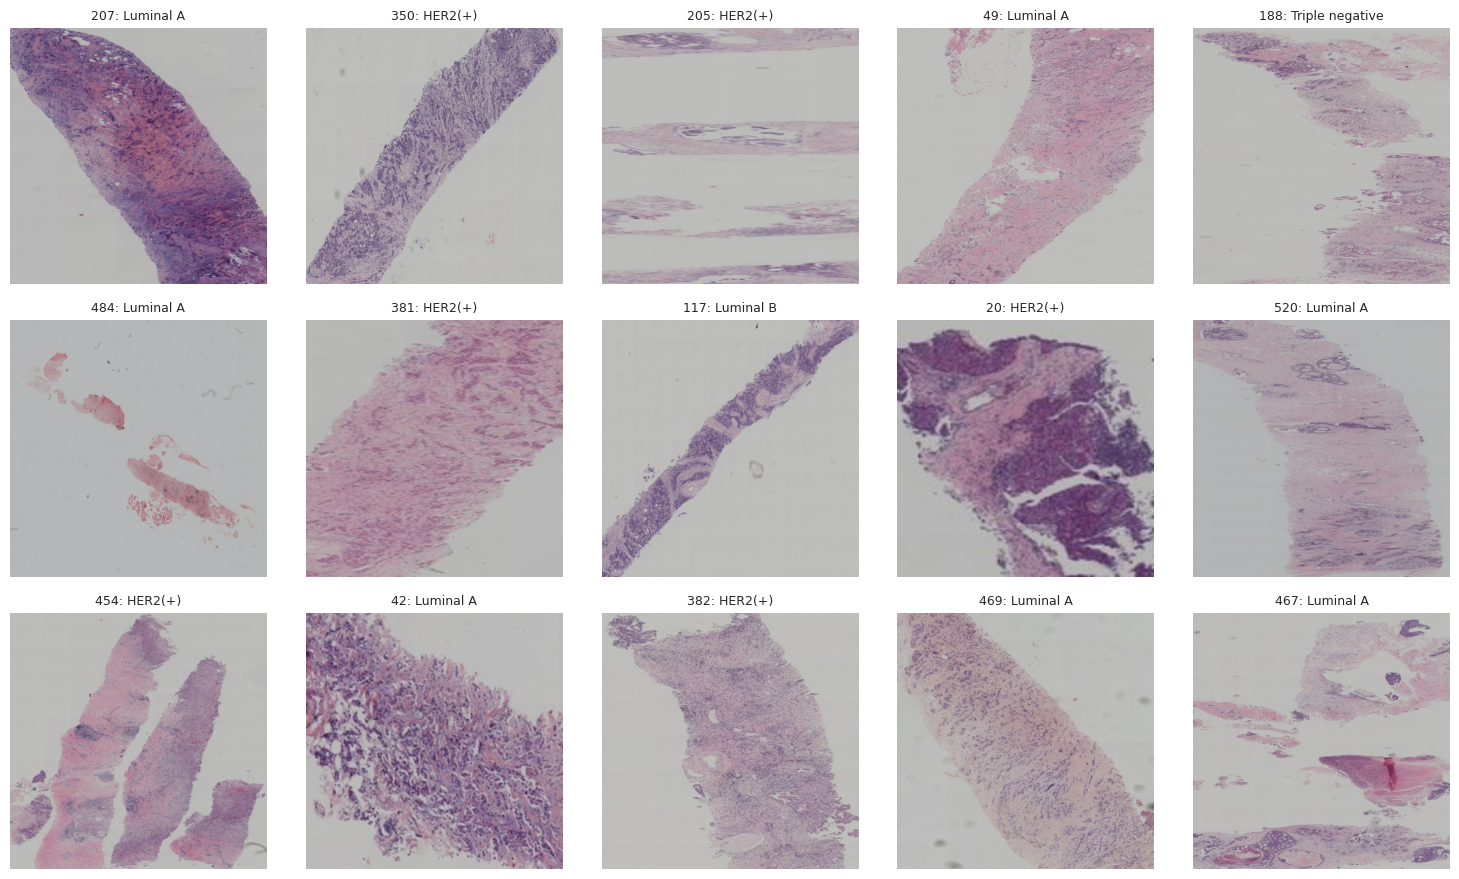

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Load preprocessed data
data = np.load("train_512_v3.npz", allow_pickle=True)
images = data["images"]          # (N, H, W, 3), uint8
labels = data["labels"]          # (N,)
label_names = data["label_names"]  # e.g. ["HER2(+)", "Luminal A", ...]

N = images.shape[0]

# choose 15 random indices without replacement
idxs = np.random.choice(N, size=15, replace=False)

plt.figure(figsize=(15, 9))

for i, idx in enumerate(idxs):
    img = images[idx]
    label_idx = labels[idx]
    label_str = str(label_names[label_idx])

    ax = plt.subplot(3, 5, i + 1)
    ax.imshow(img)
    ax.set_title(f"{idx}: {label_str}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt

data_test = np.load("test_512_v3.npz", allow_pickle=True)
imgs_t = data_test["images"]
N_t = imgs_t.shape[0]

if N_t > 0:
    idxs = np.random.choice(N_t, size=min(15, N_t), replace=False)

    plt.figure(figsize=(15, 9))
    for i, idx in enumerate(idxs):
        ax = plt.subplot(3, 5, i + 1)
        ax.imshow(imgs_t[idx])
        ax.set_title(f"idx {idx}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No test images available to display. Please ensure 'test_data' directory contains images.")

No test images available to display. Please ensure 'test_data' directory contains images.


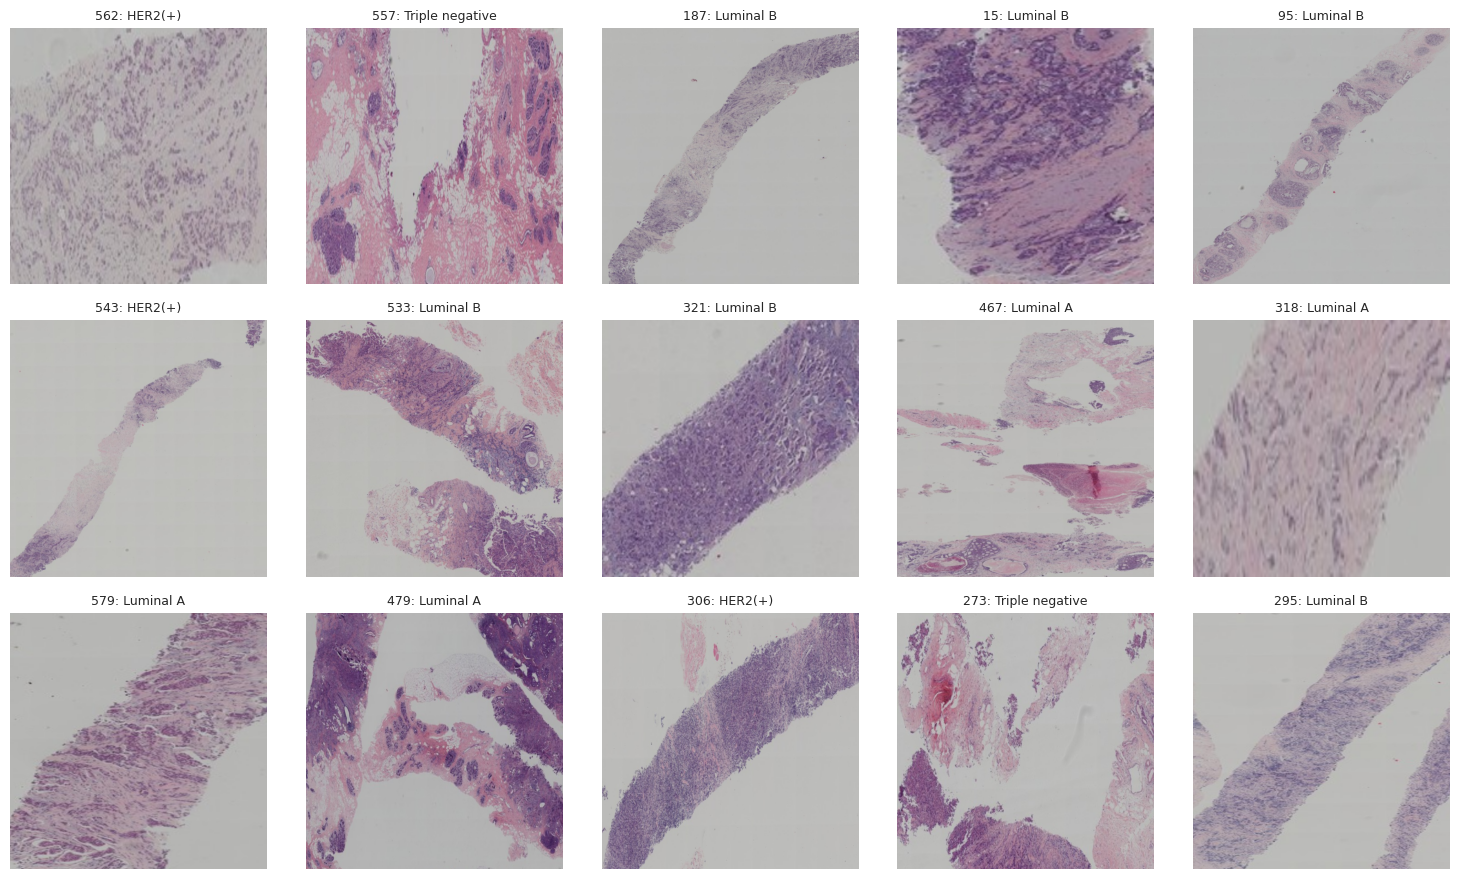

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Load preprocessed data
data = np.load("train_512_v3.npz", allow_pickle=True)
images = data["images"]          # (N, H, W, 3), uint8
labels = data["labels"]          # (N,)
label_names = data["label_names"]  # e.g. ["HER2(+)", "Luminal A", ...]

N = images.shape[0]

# choose 15 random indices without replacement
idxs = np.random.choice(N, size=15, replace=False)

plt.figure(figsize=(15, 9))

for i, idx in enumerate(idxs):
    img = images[idx]
    label_idx = labels[idx]
    label_str = str(label_names[label_idx])

    ax = plt.subplot(3, 5, i + 1)
    ax.imshow(img)
    ax.set_title(f"{idx}: {label_str}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## ResNet50


In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from torch.cuda.amp import autocast, GradScaler

# ----------------- config -----------------
DATA_DIR = Path(".")
TRAIN_NPZ = DATA_DIR / "train_512_v3.npz"
TEST_NPZ  = DATA_DIR / "test_512_v3.npz"
MODEL_PATH = DATA_DIR / "models" / "resnet50_v3_best.pt"
SUBMISSION_PATH = DATA_DIR / "submissions" / "resnet50_v3.csv"

IMG_SIZE = 512
BATCH_SIZE = 16         # you can try 12/16 if VRAM allows
EPOCHS = 80
LR = 3e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
VAL_FRACTION = 0.2
RANDOM_STATE = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs(MODEL_PATH.parent, exist_ok=True)
os.makedirs(SUBMISSION_PATH.parent, exist_ok=True)

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed()

Device: cuda


In [ ]:
# ---------- load train npz ----------
train_data = np.load(TRAIN_NPZ, allow_pickle=True)
X_all = train_data["images"]              # (N, H, W, 3), uint8
y_all = train_data["labels"]             # (N,)
label_names = train_data["label_names"]  # array of strings
filenames_train = train_data["filenames"]

num_classes = len(label_names)
print("Train images:", X_all.shape, "num_classes:", num_classes, label_names)

# class counts (for weights)
class_counts = np.bincount(y_all, minlength=num_classes)
print("Class counts:", class_counts)

# ---------- stratified train/val split ----------
idx_all = np.arange(len(y_all))
train_idx, val_idx = train_test_split(
    idx_all,
    test_size=VAL_FRACTION,
    stratify=y_all,
    random_state=RANDOM_STATE
)
print("Train/val sizes:", len(train_idx), len(val_idx))


Train images: (631, 512, 512, 3) num_classes: 4 ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']
Class counts: [159 175 220  77]
Train/val sizes: 504 127


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class NPZTissueDataset(Dataset):
    def __init__(self, images, labels=None, indices=None, train=True):
        self.images = images
        self.labels = labels
        self.indices = np.arange(len(images)) if indices is None else np.array(indices)
        self.train = train

        if train:
            self.transform = T.Compose([
                T.ToPILImage(),
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.RandomRotation(10),
                T.ColorJitter(brightness=0.15, contrast=0.15,
                              saturation=0.10, hue=0.02),
                T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ])
        else:
            self.transform = T.Compose([
                T.ToPILImage(),
                T.Resize(int(IMG_SIZE * 1.02)),
                T.CenterCrop(IMG_SIZE),
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = self.images[real_idx]        # (H, W, 3), uint8
        img = self.transform(img)

        if self.labels is None:
            return img
        else:
            label = int(self.labels[real_idx])
            return img, label

# datasets & loaders
train_ds = NPZTissueDataset(X_all, y_all, indices=train_idx, train=True)
val_ds   = NPZTissueDataset(X_all, y_all, indices=val_idx,   train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

len(train_loader), len(val_loader)

(32, 8)

In [ ]:
# ---------- model ----------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
# ---- warmup: freeze lower layers ----
for param in model.layer1.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = False
for param in model.layer3.parameters():
    param.requires_grad = False

warmup_epochs = 3  # number of epochs to keep them frozen
print("Frozen layers: layer1, layer2, layer3 for warmup.")


# ---------- loss with class weights + label smoothing ----------
class_weights = torch.tensor(
    (class_counts.sum() / (class_counts + 1e-6)),
    dtype=torch.float32,
    device=device,
)
class_weights = class_weights / class_weights.mean()

try:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING
    )
except TypeError:
    # older PyTorch without label_smoothing
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print("CrossEntropyLoss without label_smoothing (PyTorch too old).")

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler()

Frozen layers: layer1, layer2, layer3 for warmup.


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    running_loss = 0.0
    all_targets = []
    all_preds = []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)

        preds = outputs.argmax(dim=1)
        all_targets.append(labels.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return epoch_loss, macro_f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_preds = []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_targets.append(labels.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return epoch_loss, macro_f1

In [ ]:
best_val_f1 = 0.0
patience = 12
patience_counter = 0

history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
warmup_done = False

for epoch in range(1, EPOCHS + 1):

    # ---- unfreeze after warmup ----
    if (not warmup_done) and (epoch == warmup_epochs + 1):
        print(f"Unfreezing layers 1–3 at epoch {epoch}.")
        for param in model.layer1.parameters():
            param.requires_grad = True
        for param in model.layer2.parameters():
            param.requires_grad = True
        for param in model.layer3.parameters():
            param.requires_grad = True
        warmup_done = True
        # no need to recreate optimizer; newly-unfrozen params will start getting grads

    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, scaler, epoch)
    val_loss, val_f1 = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"train_f1={train_f1:.4f}, val_f1={val_f1:.4f}, "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    # checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save({
            "model_state": model.state_dict(),
            "best_val_f1": best_val_f1,
            "label_names": label_names,
        }, MODEL_PATH)
        print(f"  ↳ New best model saved with val_f1={best_val_f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 01/80 | train_loss=1.4132, val_loss=1.4045, train_f1=0.2421, val_f1=0.2050, lr=3.00e-05
  ↳ New best model saved with val_f1=0.2050
Epoch 02/80 | train_loss=1.3981, val_loss=1.4018, train_f1=0.2979, val_f1=0.2671, lr=3.00e-05
  ↳ New best model saved with val_f1=0.2671
Epoch 03/80 | train_loss=1.3807, val_loss=1.4000, train_f1=0.3497, val_f1=0.2394, lr=2.99e-05
Unfreezing layers 1–3 at epoch 4.
Epoch 04/80 | train_loss=1.3686, val_loss=1.3974, train_f1=0.3479, val_f1=0.2496, lr=2.98e-05
Epoch 05/80 | train_loss=1.3534, val_loss=1.3969, train_f1=0.3484, val_f1=0.2770, lr=2.97e-05
  ↳ New best model saved with val_f1=0.2770
Epoch 06/80 | train_loss=1.3323, val_loss=1.3938, train_f1=0.3810, val_f1=0.2826, lr=2.96e-05
  ↳ New best model saved with val_f1=0.2826
Epoch 07/80 | train_loss=1.3120, val_loss=1.3815, train_f1=0.4304, val_f1=0.3227, lr=2.94e-05
  ↳ New best model saved with val_f1=0.3227
Epoch 08/80 | train_loss=1.2852, val_loss=1.3866, train_f1=0.4191, val_f1=0.3442, lr=2.9

## Submission


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from torch.cuda.amp import autocast
from pathlib import Path

# paths
TEST_NPZ = "test_512_v3.npz"
MODEL_PATH = "models/resnet50_v3_best.pt"
SUBMISSION_BASE = "submissions/resnet50_no_tta.csv"

IMG_SIZE = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_test = np.load(TEST_NPZ, allow_pickle=True)
X_test = data_test["images"]
test_filenames = data_test["filenames"]
label_names = np.load("train_512_v3.npz", allow_pickle=True)["label_names"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class TestDatasetNoTTA(Dataset):
    def __init__(self, X):
        self.X = X
        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize(int(IMG_SIZE * 1.02)),
            T.CenterCrop(IMG_SIZE),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.transform(self.X[idx])

test_ds = TestDatasetNoTTA(X_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

# load best model
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, len(label_names))
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

all_preds = []

with torch.no_grad():
    for imgs in test_loader:
        imgs = imgs.to(device)
        with autocast():
            outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

pred_labels = [str(label_names[i]) for i in all_preds]

submission = pd.DataFrame({
    "sample_index": test_filenames,
    "label": pred_labels
})
submission.to_csv(SUBMISSION_BASE, index=False)
print("Saved baseline submission:", SUBMISSION_BASE)
submission.head()

Saved baseline submission: submissions/resnet50_no_tta.csv


,sample_index,label
0,img_0000.png,Luminal A
1,img_0001.png,Luminal B
2,img_0002.png,Luminal A
3,img_0003.png,Luminal B
4,img_0004.png,Luminal A


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from torch.cuda.amp import autocast
from pathlib import Path

TTA_TIMES = 5
SUBMISSION_TTA = "submissions/resnet50_tta.csv"

class TestDatasetTTA(Dataset):
    def __init__(self, X):
        self.X = X
        self.base_transform = T.Compose([
            T.ToPILImage(),
            T.Resize(int(IMG_SIZE * 1.02)),
            T.CenterCrop(IMG_SIZE),
        ])
        self.tta_transform = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.2),
            T.RandomRotation(degrees=7),
        ])
        self.final_norm = T.Compose([
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        img = self.base_transform(img)
        imgs_tta = []
        for _ in range(TTA_TIMES):
            aug = self.tta_transform(img.copy())
            aug = self.final_norm(aug)
            imgs_tta.append(aug)
        return torch.stack(imgs_tta)   # shape (TTA_TIMES, C, H, W)

test_ds_tta = TestDatasetTTA(X_test)
test_loader_tta = DataLoader(test_ds_tta, batch_size=4, shuffle=False, num_workers=2)

# load model again
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, len(label_names))
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

tta_preds = []

with torch.no_grad():
    for batch in test_loader_tta:
        # batch shape: (B, TTA, C, H, W)
        B, TTA, C, H, W = batch.shape
        batch = batch.to(device)
        batch = batch.view(B*TTA, C, H, W)

        with autocast():
            logits = model(batch)

        logits = logits.view(B, TTA, -1)          # (B, TTA, num_classes)
        logits_mean = logits.mean(dim=1)          # average across TTA passes

        preds = logits_mean.argmax(dim=1).cpu().numpy()
        tta_preds.extend(preds)

pred_labels_tta = [str(label_names[i]) for i in tta_preds]

submission_tta = pd.DataFrame({
    "sample_index": test_filenames,
    "label": pred_labels_tta
})
submission_tta.to_csv(SUBMISSION_TTA, index=False)
print("Saved TTA submission:", SUBMISSION_TTA)
submission_tta.head()

Saved TTA submission: submissions/resnet50_tta.csv


,sample_index,label
0,img_0000.png,Luminal A
1,img_0001.png,Luminal A
2,img_0002.png,Luminal A
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B
